In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [2]:
# Additional imports for visualization
import squarify
import pypalettes
import highlight_text

In [3]:
df = pd.read_csv("../data/superstore_cleaned.csv")

In [4]:
df['order_date'] = pd.to_datetime(df['order_date']).dt.date
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub_category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

In [5]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_name,sales,quantity,discount,profit,profit_margin,order_year,order_month,order_qarter,days_to_ship
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00,2016,11,4,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00,2016,11,4,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00,2016,6,2,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00,2015,10,4,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25,2015,10,4,7


In [6]:
df.tail()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_name,sales,quantity,discount,profit,profit_margin,order_year,order_month,order_qarter,days_to_ship
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Ultra Door Pull Handle,25.248,3,0.2,4.1028,16.25,2014,1,1,2
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332,17.00,2017,2,1,5
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,7.50,2017,2,1,5
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,45.00,2017,2,1,5
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480,30.00,2017,5,2,5


In [7]:
# Latest purchase date in relation to the dataset
max_date = df["order_date"].max()

date_format = "%Y-%m-%d"

latest_date = max_date + timedelta(days=1)
# latest_date = latest_datetime.date()


print("Latest purchase date in relation to the data set: ", latest_date)


Latest purchase date in relation to the data set:  2017-12-31


In [8]:
# Customer RFM

customer_rfm = df.groupby(['customer_id']).agg({
    "customer_name": "first",
    "order_date": lambda x: (latest_date - x.max()).days,
    "order_id": "count",
    "profit": "sum"
})

customer_rfm

,customer_name,order_date,order_id,profit
customer_id,,,,
AA-10315,Alex Avila,185,11,-362.8825
AA-10375,Allen Armold,20,15,277.3824
AA-10480,Andrew Allen,260,12,435.8274
AA-10645,Anna Andreadi,56,18,857.8033
AB-10015,Aaron Bergman,416,6,129.3465
...,...,...,...,...
XP-21865,Xylona Preis,44,28,621.2300
YC-21895,Yoseph Carroll,5,8,1305.6290
YS-21880,Yana Sorensen,10,12,1778.2923


In [9]:
# Segment the data

customer_quantiles = customer_rfm.quantile([0.2, 0.4, 0.6, 0.8], numeric_only=True)

In [10]:
def recency_score(row):
    if row < customer_quantiles.loc[0.2]['order_date']:
        return 5
    elif row < customer_quantiles.loc[0.4]['order_date']:
        return 4
    elif row < customer_quantiles.loc[0.6]['order_date']:
        return 3
    elif row < customer_quantiles.loc[0.8]['order_date']:
        return 2
    else:
        return 1

def frequency_score(row):
    if row < customer_quantiles.loc[0.2]['order_id']:
        return 1
    elif row < customer_quantiles.loc[0.4]['order_id']:
        return 2
    elif row < customer_quantiles.loc[0.6]['order_id']:
        return 3
    elif row < customer_quantiles.loc[0.8]['order_id']:
        return 4
    else:
        return 5

def monetary_score(row):
    if row < customer_quantiles.loc[0.2]['profit']:
        return 1
    elif row < customer_quantiles.loc[0.4]['profit']:
        return 2
    elif row < customer_quantiles.loc[0.6]['profit']:
        return 3
    elif row < customer_quantiles.loc[0.8]['profit']:
        return 4
    else:
        return 5

customer_rfm['order_date'] = customer_rfm['order_date'].apply(recency_score)
customer_rfm['order_id'] = customer_rfm['order_id'].apply(frequency_score)
customer_rfm['profit'] = customer_rfm['profit'].apply(monetary_score)

In [11]:
customer_rfm

,customer_name,order_date,order_id,profit
customer_id,,,,
AA-10315,Alex Avila,2,3,1
AA-10375,Allen Armold,5,4,3
AA-10480,Andrew Allen,1,3,4
AA-10645,Anna Andreadi,3,5,5
AB-10015,Aaron Bergman,1,1,2
...,...,...,...,...
XP-21865,Xylona Preis,4,5,4
YC-21895,Yoseph Carroll,5,2,5
YS-21880,Yana Sorensen,5,3,5


In [12]:
# Quickly Rename columns for convenience

customer_rfm = customer_rfm.rename(
    columns={
            'order_date': 'Recency', 
            'order_id': 'Frequency',
            'profit': 'Monetary'
        })


In [16]:
# Customer segment column and overall score

def customer_score(row):
    totalScore = row['Recency'] + row['Frequency'] + row['Monetary']

    if totalScore <= 6:
        return 'Low Priority'
    elif totalScore <= 10:
        return 'Mid Priority'
    else:
        return 'High Priority'

customer_rfm['customer_segment'] = customer_rfm.apply(lambda row: f"{row['Recency']}{row['Frequency']}{row['Monetary']}", axis=1)
customer_rfm['customer_score'] = customer_rfm.apply(customer_score, axis=1)


In [17]:
customer_rfm

,customer_name,Recency,Frequency,Monetary,customer_segment,customer_score,FM_Score
customer_id,,,,,,,
AA-10315,Alex Avila,2,3,1,231,Low Priority,2.0
AA-10375,Allen Armold,5,4,3,543,High Priority,3.5
AA-10480,Andrew Allen,1,3,4,134,Mid Priority,3.5
AA-10645,Anna Andreadi,3,5,5,355,High Priority,5.0
AB-10015,Aaron Bergman,1,1,2,112,Low Priority,1.5
...,...,...,...,...,...,...,...
XP-21865,Xylona Preis,4,5,4,454,High Priority,4.5
YC-21895,Yoseph Carroll,5,2,5,525,High Priority,3.5
YS-21880,Yana Sorensen,5,3,5,535,High Priority,4.0


In [15]:
customer_rfm['FM_Score'] = (customer_rfm['Frequency'] + customer_rfm['Monetary']) / 2

customer_rfm

,customer_name,Recency,Frequency,Monetary,customer_segment,customer_score,FM_Score
customer_id,,,,,,,
AA-10315,Alex Avila,2,3,1,231,Mid Priority,2.0
AA-10375,Allen Armold,5,4,3,543,High Priority,3.5
AA-10480,Andrew Allen,1,3,4,134,Mid Priority,3.5
AA-10645,Anna Andreadi,3,5,5,355,High Priority,5.0
AB-10015,Aaron Bergman,1,1,2,112,Low Priority,1.5
...,...,...,...,...,...,...,...
XP-21865,Xylona Preis,4,5,4,454,High Priority,4.5
YC-21895,Yoseph Carroll,5,2,5,525,High Priority,3.5
YS-21880,Yana Sorensen,5,3,5,535,High Priority,4.0


In [19]:
def assign_segment(row):
    r, f, m = row["Recency"], row["Frequency"], row["Monetary"]

    if 4 <= r <= 5 and 4 <= f <= 5 and 4 <= m <= 5:
        return "Champions"
    elif r < 2 and 4 <= f <= 5 and 4 <= m <= 5:
        return "Can't Lose Them"
    elif 2 <= r <= 4 and 3 <= f <= 4 and 4 <= m <= 5:
        return "Loyal Customers"
    elif 4 <= r <= 5 and f < 2 and m < 2:
        return "New Customers"
    elif 3 <= r <= 4 and f < 2 and m < 2:
        return "Promising"
    elif 3 <= r <= 4 and 3 <= f <= 4 and 3 <= m <= 4:
        return "Need Attention"
    elif r < 2 and f < 2 and m < 2:
        return "Lost"
    elif 2 <= r <= 3 and 2 <= f <= 3 and 2 <= m <= 3:
        return "Hibernating"
    elif 2 <= r <= 3 and f < 3 and m < 3:
        return "About to Sleep"
    elif 3 <= r <= 5 and 1 <= f <= 3 and 1 <= m <= 3:
        return "Potential Loyalists"
    elif r < 3 and 2 <= f <= 5 and 2 <= m <= 5:
        return "At Risk"
    else:
        return "Other"

customer_rfm["Segment"] = customer_rfm.apply(assign_segment, axis=1)

# always check this after — see note below
print(customer_rfm["Segment"].value_counts())

Segment
Other                  228
At Risk                110
Champions              102
Potential Loyalists     88
Loyal Customers         87
Hibernating             57
About to Sleep          40
Need Attention          32
Lost                    21
Can't Lose Them         20
Promising                4
New Customers            4
Name: count, dtype: int64


<Axes: >

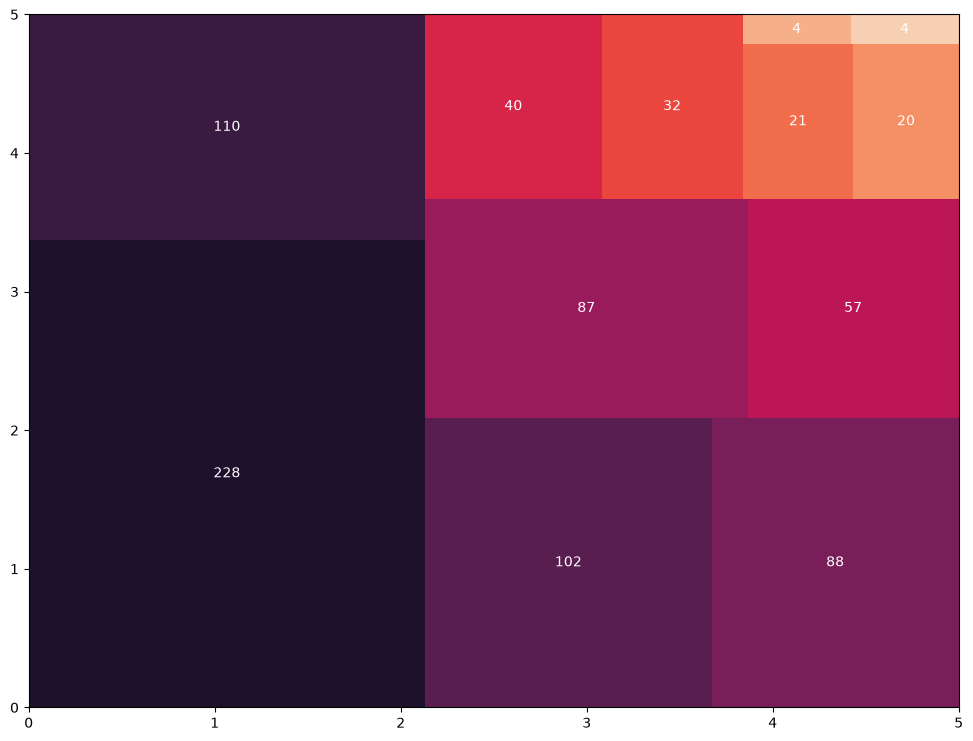

In [ ]:
plt.figure(figsize=(12, 9))

customer_rfm["Segment"].value_counts()

squarify.plot(sizes=customer_rfm["Segment"].value_counts(), 
              label = customer_rfm["Segment"].value_counts(),
              text_kwargs = {'fontsize': 10, 'color': 'white'},
              color=sns.color_palette("rocket", len(customer_rfm["Segment"].value_counts())),
              norm_x=5, norm_y=5)